In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, GridSearchCV)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, matthews_corrcoef, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

In [2]:
# 1. LOAD DATA

df = pd.read_csv("surface_wqi_pred.csv")
print(f"Original dataset shape: {df.shape}")
print(f"\nMissing values:\n{df.isna().sum()}")

Original dataset shape: (42, 23)

Missing values:
Site                               0
Year                               0
pH                                 0
Odour                             42
Turbidity                          0
Conductivity                       0
Chloride (ppm)                     0
Sulphates(ppm)                     0
Iron (ppm)                         0
COD(ppm)                           0
BOD(ppm)                           0
DO(ppm)                            0
Lead(ppm)                         42
Ammonia(ppm)                       0
Nitrate(ppm)                       0
Fluorides(ppm)                    30
Phosphates(ppm)                   41
Total Bacterial Count (cfu/ml)     0
Total Fungal Count (cfu/ml)       18
Pesticide (µg/l)                  42
WQI                                0
WQI_Class                          0
WQI_Pred                          29
dtype: int64



WQI Class distribution:
WQI_Class
Medium       19
Poor         19
Good          2
Very Poor     2
Name: count, dtype: int64


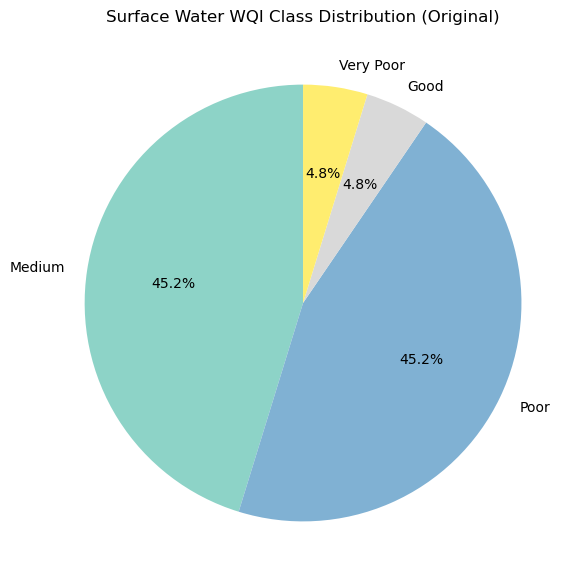

Saved: class_distribution.png


In [3]:
# 2. CLASS DISTRIBUTION (before any processing)

print(f"\nWQI Class distribution:\n{df['WQI_Class'].value_counts()}")

plt.figure(figsize=(6, 6))
df["WQI_Class"].value_counts().plot(kind="pie", autopct="%1.1f%%",
                                     startangle=90, cmap="Set3")
plt.title("Surface Water WQI Class Distribution (Original)")
plt.ylabel("")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()
print("Saved: class_distribution.png")

In [4]:
# 3. DROP LEAKY / USELESS COLUMNS

# WQI       → numerical value WQI_Class is derived from → perfect leakage
# WQI_Pred  → partial target column (only 13/42 filled) → leakage
# WQI_Class → the target itself (kept separately as y)
# 100%-NaN & near-empty columns (Odour, Lead, Pesticide, Phosphates)
always_nan_or_useless = [
    col for col in df.columns
    if df[col].isna().all() or df[col].isna().sum() >= len(df) - 1
]
print(f"\nDropping near-empty columns: {always_nan_or_useless}")
df.drop(columns=always_nan_or_useless, errors='ignore', inplace=True)

for col in ["WQI", "WQI_Pred", "WQI_Class_Encoded", "Hotspot"]:
    if col in df.columns:
        print(f"Dropping '{col}' — target leakage")
        df.drop(columns=[col], inplace=True)


Dropping near-empty columns: ['Odour', 'Lead(ppm)', 'Phosphates(ppm)', 'Pesticide (µg/l)']
Dropping 'WQI' — target leakage
Dropping 'WQI_Pred' — target leakage


In [5]:
# ENCODE TARGET

le = LabelEncoder()
df["WQI_Class_Encoded"] = le.fit_transform(df["WQI_Class"])
class_names = le.classes_
print(f"\nClass encoding: {dict(zip(le.transform(class_names), class_names))}")


Class encoding: {0: 'Good', 1: 'Medium', 2: 'Poor', 3: 'Very Poor'}


In [7]:
#FEATURE / TARGET SPLIT

X = df.select_dtypes(include="number").drop(columns=["WQI_Class_Encoded"])
y = df["WQI_Class_Encoded"]

In [8]:
# CHECK IRON (ppm) FOR LEAKAGE

if "Iron (ppm)" in X.columns:
    # Compute correlation with original WQI (if still available in df)
    if "WQI" in df.columns:
        iron_corr = abs(X["Iron (ppm)"].corr(df["WQI"]))
    else:
        # Proxy: correlation with encoded class label
        iron_corr = abs(X["Iron (ppm)"].corr(y))
    print(f"\nIron (ppm) correlation with target: {iron_corr:.4f}")
    if iron_corr > 0.95:
        print("Iron (ppm) near-perfectly predicts target → dropping (leakage)")
        X = X.drop(columns=["Iron (ppm)"])
    else:
        print("Iron (ppm) correlation acceptable — keeping as feature")

print(f"\nFinal features ({X.shape[1]}): {list(X.columns)}")
print(f"Dataset size: {X.shape}")
print(f"\nRemaining missing values:\n{X.isna().sum().sort_values(ascending=False)}")


Iron (ppm) correlation with target: 0.2516
Iron (ppm) correlation acceptable — keeping as feature

Final features (15): ['Year', 'pH', 'Turbidity', 'Conductivity', 'Chloride (ppm)', 'Sulphates(ppm)', 'Iron (ppm)', 'COD(ppm)', 'BOD(ppm)', 'DO(ppm)', 'Ammonia(ppm)', 'Nitrate(ppm)', 'Fluorides(ppm)', 'Total Bacterial Count (cfu/ml)', 'Total Fungal Count (cfu/ml)']
Dataset size: (42, 15)

Remaining missing values:
Fluorides(ppm)                    30
Total Fungal Count (cfu/ml)       18
Year                               0
pH                                 0
Turbidity                          0
Conductivity                       0
Chloride (ppm)                     0
Sulphates(ppm)                     0
Iron (ppm)                         0
COD(ppm)                           0
BOD(ppm)                           0
DO(ppm)                            0
Ammonia(ppm)                       0
Nitrate(ppm)                       0
Total Bacterial Count (cfu/ml)     0
dtype: int64


In [9]:
# 7. TRAIN-TEST SPLIT (stratified — before any augmentation/imputation)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")
print(f"Train class distribution:\n{pd.Series(y_train).value_counts()}")


Train: (33, 15), Test: (9, 15)
Train class distribution:
WQI_Class_Encoded
1    15
2    15
0     2
3     1
Name: count, dtype: int64


In [10]:
# 8. DATA AUGMENTATION — Gaussian noise (training set only)

def augment_data(X, y, n_copies=3, noise_fraction=0.01, random_state=42):
    """
    Expand dataset by creating n_copies noisy versions of each training sample.
    Noise = Gaussian with std = noise_fraction × feature_std.
    Only applied to non-NaN values to preserve missing patterns.
    """
    rng = np.random.RandomState(random_state)
    feature_stds = X.std(skipna=True)
    X_list, y_list = [X.copy()], [y.copy()]
    for _ in range(n_copies):
        X_noisy = X.copy()
        for col in X.columns:
            std = feature_stds[col]
            if std == 0 or np.isnan(std):
                continue
            noise = rng.normal(0, noise_fraction * std, size=len(X))
            mask = X_noisy[col].notna()
            X_noisy.loc[mask, col] = X_noisy.loc[mask, col] + noise[mask]
        X_list.append(X_noisy)
        y_list.append(y.copy())  # labels unchanged for classification
    return pd.concat(X_list, ignore_index=True), pd.concat(y_list, ignore_index=True)

X_train_aug, y_train_aug = augment_data(X_train, y_train, n_copies=3)
print(f"\nAfter Gaussian augmentation: train={X_train_aug.shape}")


After Gaussian augmentation: train=(132, 15)


In [12]:
#KNN IMPUTATION (fit on training only)

imputer = KNNImputer(n_neighbors=5)
X_train_imp = imputer.fit_transform(X_train_aug)
X_test_imp  = imputer.transform(X_test)

In [13]:
#FEATURE SCALING

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_imp)
X_test_sc  = scaler.transform(X_test_imp)

In [14]:
# 11. SMOTE (applied after imputation/scaling, training only)

min_class_count = pd.Series(y_train_aug).value_counts().min()
k_neighbors = min(5, min_class_count - 1)
print(f"\nClass distribution before SMOTE:\n{pd.Series(y_train_aug).value_counts()}")

if k_neighbors >= 1:
    smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
    X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train_aug)
    print(f"Class distribution after SMOTE:\n{pd.Series(y_train_sm).value_counts()}")
    print(f"Final training shape: {X_train_sm.shape}")
else:
    print("Not enough samples for SMOTE — skipping, using augmented data only")
    X_train_sm, y_train_sm = X_train_sc, y_train_aug


Class distribution before SMOTE:
WQI_Class_Encoded
1    60
2    60
0     8
3     4
Name: count, dtype: int64
Class distribution after SMOTE:
WQI_Class_Encoded
1    60
2    60
0    60
3    60
Name: count, dtype: int64
Final training shape: (240, 15)


In [15]:
# 12. HYPERPARAMETER TUNING (GridSearchCV)

print("\n--- Hyperparameter Tuning ---")

param_grids = {
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "n_estimators": [50, 100, 200],
            "max_depth": [None, 5, 10],
            "min_samples_split": [2, 5]
        }
    },
    "Gradient Boosting": {
        "model": GradientBoostingClassifier(random_state=42),
        "params": {
            "n_estimators": [50, 100],
            "learning_rate": [0.05, 0.1, 0.2],
            "max_depth": [3, 5]
        }
    },
    "XGBoost": {
        "model": XGBClassifier(eval_metric="mlogloss", random_state=42, verbosity=0),
        "params": {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.05, 0.1],
            "max_depth": [3, 5]
        }
    },
    "SVM": {
        "model": SVC(probability=True, random_state=42),
        "params": {
            "C": [1, 10, 100],
            "gamma": ["scale", "auto", 0.1],
            "kernel": ["rbf", "linear"]
        }
    },
    "KNN": {
        "model": KNeighborsClassifier(),
        "params": {
            "n_neighbors": [3, 5, 7, 9],
            "weights": ["uniform", "distance"],
            "metric": ["euclidean", "manhattan"]
        }
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "params": {
            "max_depth": [None, 3, 5, 10],
            "min_samples_split": [2, 5, 10],
            "criterion": ["gini", "entropy"]
        }
    }
}

# StratifiedKFold — correct for classification (fixed from plain KFold)
# 5-fold only — 10-fold risks single-sample folds on augmented minority classes
skf5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_models   = {}
final_results = []

for name, cfg in param_grids.items():
    grid = GridSearchCV(cfg["model"], cfg["params"], cv=5,
                        scoring="f1_weighted", n_jobs=-1)
    grid.fit(X_train_sm, y_train_sm)
    best_model = grid.best_estimator_
    best_models[name] = best_model

    y_pred = best_model.predict(X_test_sc)

    acc       = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    recall    = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1        = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    mcc       = matthews_corrcoef(y_test, y_pred)

    # CV on SMOTE training data only (fixed: original used full X/y)
    cv5 = cross_val_score(best_model, X_train_sm, y_train_sm,
                          cv=skf5, scoring="accuracy")

    print(f"{name}: Acc={acc:.3f} | F1={f1:.3f} | Best: {grid.best_params_}")

    final_results.append([
        name, round(acc, 4), round(precision, 4), round(recall, 4),
        round(f1, 4), round(mcc, 4),
        f"{cv5.mean():.3f} ± {cv5.std():.3f}"
    ])


--- Hyperparameter Tuning ---
Random Forest: Acc=0.778 | F1=0.728 | Best: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Gradient Boosting: Acc=0.889 | F1=0.887 | Best: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
XGBoost: Acc=0.778 | F1=0.778 | Best: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
SVM: Acc=0.333 | F1=0.309 | Best: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
KNN: Acc=0.778 | F1=0.728 | Best: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
Decision Tree: Acc=1.000 | F1=1.000 | Best: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2}


In [16]:
# 13. RESULTS TABLE
# ─────────────────────────────────────────────
columns = ["Model", "Accuracy", "Precision", "Recall", "F1 Score", "MCC", "5-Fold CV Acc"]
results_df = pd.DataFrame(final_results, columns=columns)
results_df = results_df.sort_values(by="F1 Score", ascending=False).reset_index(drop=True)

print("\n=== SURFACE WATER CLASSIFICATION RESULTS ===")
print(results_df.to_string(index=False))


=== SURFACE WATER CLASSIFICATION RESULTS ===
            Model  Accuracy  Precision  Recall  F1 Score     MCC 5-Fold CV Acc
    Decision Tree    1.0000     1.0000  1.0000    1.0000  1.0000 0.996 ± 0.008
Gradient Boosting    0.8889     0.9111  0.8889    0.8871  0.8300 1.000 ± 0.000
          XGBoost    0.7778     0.7778  0.7778    0.7778  0.6250 0.992 ± 0.010
    Random Forest    0.7778     0.6889  0.7778    0.7284  0.6162 1.000 ± 0.000
              KNN    0.7778     0.6889  0.7778    0.7284  0.6162 0.988 ± 0.025
              SVM    0.3333     0.2889  0.3333    0.3086 -0.2054 0.979 ± 0.026


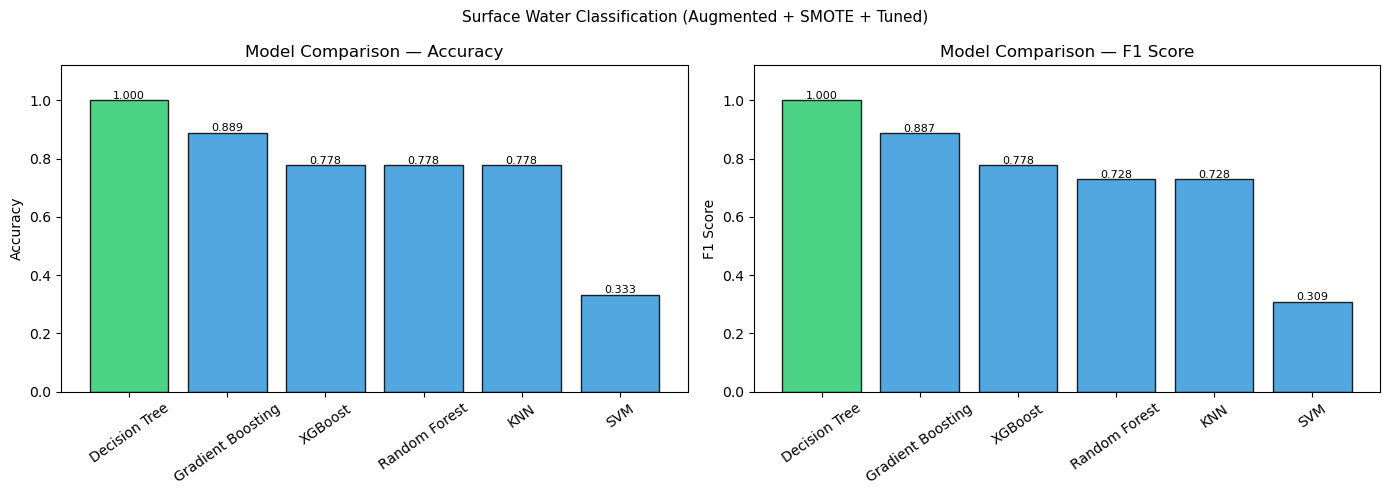

Saved: model_comparison.png

=== Classification Report: Decision Tree ===
              precision    recall  f1-score   support

      Medium       1.00      1.00      1.00         4
        Poor       1.00      1.00      1.00         4
   Very Poor       1.00      1.00      1.00         1

    accuracy                           1.00         9
   macro avg       1.00      1.00      1.00         9
weighted avg       1.00      1.00      1.00         9



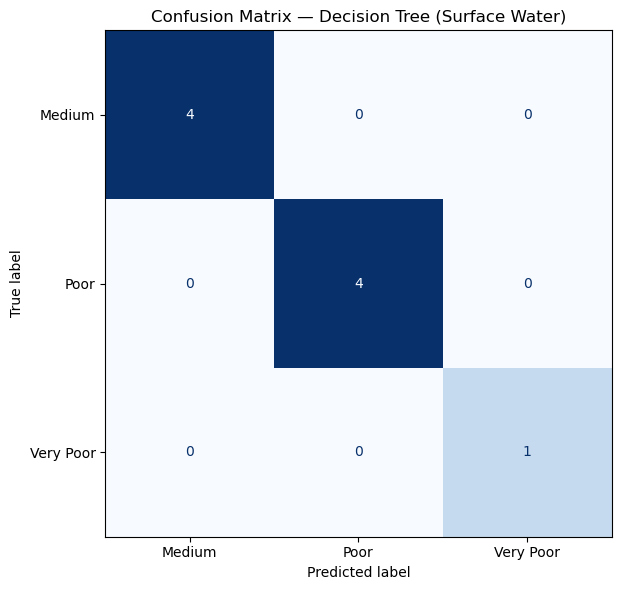

Saved: confusion_matrix.png


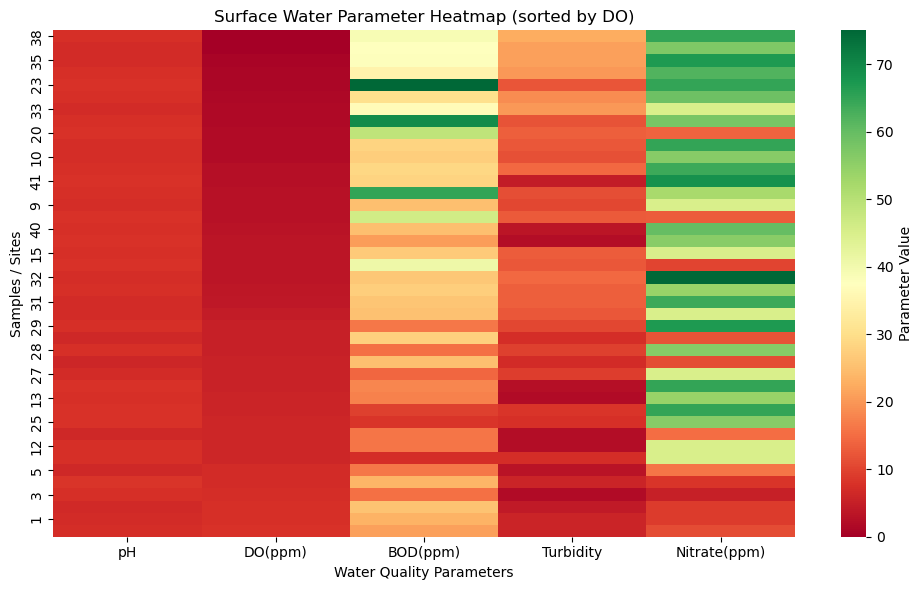

Saved: parameter_heatmap.png


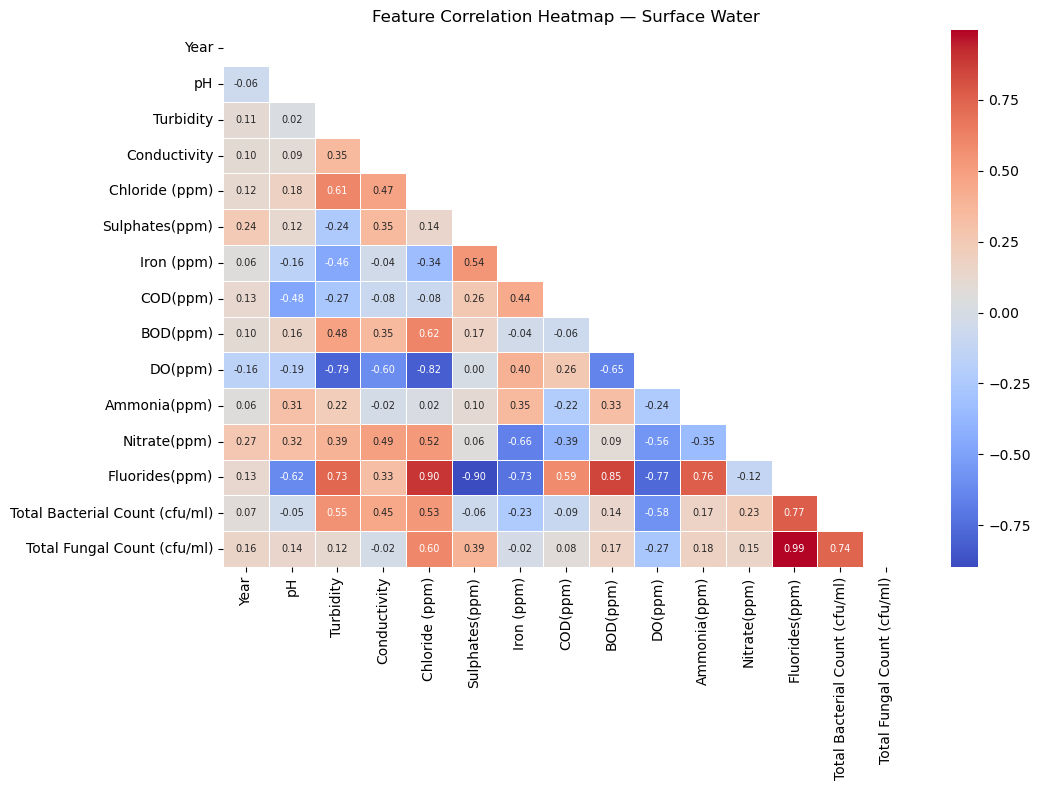

Saved: correlation_heatmap.png


In [21]:
# PLOTS

# Model comparison — Accuracy & F1 side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric in zip(axes, ["Accuracy", "F1 Score"]):
    bar_colors = ['#2ecc71' if v == results_df[metric].max() else '#3498db'
                  for v in results_df[metric]]
    bars = ax.bar(results_df["Model"], results_df[metric],
                  color=bar_colors, edgecolor='black', alpha=0.85)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', fontsize=8)
    ax.set_title(f"Model Comparison — {metric}")
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.12)
    ax.tick_params(axis='x', rotation=35)
plt.suptitle("Surface Water Classification (Augmented + SMOTE + Tuned)", fontsize=11)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()
print("Saved: model_comparison.png")
 
# Confusion matrix — best model (fixed: original used stale y_pred from last loop)
best_name   = results_df.iloc[0]["Model"]
best_model  = best_models[best_name]
y_pred_best = best_model.predict(X_test_sc)
 
print(f"\n=== Classification Report: {best_name} ===")
# Use only labels present in y_test to avoid mismatch with class_names length
present_labels      = sorted(y_test.unique())
present_class_names = [class_names[i] for i in present_labels]
print(classification_report(y_test, y_pred_best,
                             labels=present_labels,
                             target_names=present_class_names,
                             zero_division=0))
 
cm = confusion_matrix(y_test, y_pred_best, labels=present_labels)
 
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=present_class_names)
disp.plot(cmap="Blues", ax=ax, colorbar=False)
ax.set_title(f"Confusion Matrix — {best_name} (Surface Water)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("Saved: confusion_matrix.png")
 
# NSF-style parameter heatmap (raw values from original df)
qi_cols = [c for c in ["pH", "DO(ppm)", "BOD(ppm)", "Turbidity", "Nitrate(ppm)"]
           if c in df.columns]
if qi_cols:
    sort_col = "DO(ppm)" if "DO(ppm)" in qi_cols else qi_cols[0]
    plt.figure(figsize=(10, 6))
    sns.heatmap(
        df[qi_cols].sort_values(sort_col),
        cmap="RdYlGn",
        cbar_kws={"label": "Parameter Value"}
    )
    plt.title("Surface Water Parameter Heatmap (sorted by DO)")
    plt.xlabel("Water Quality Parameters")
    plt.ylabel("Samples / Sites")
    plt.tight_layout()
    plt.savefig("parameter_heatmap.png", dpi=150)
    plt.show()
    print("Saved: parameter_heatmap.png")
 
# Correlation heatmap
plt.figure(figsize=(11, 8))
corr_cols = df.select_dtypes(include="number").drop(columns=["WQI_Class_Encoded"],
                                                     errors="ignore")
corr = corr_cols.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
            annot_kws={"size": 7}, linewidths=0.4)
plt.title("Feature Correlation Heatmap — Surface Water")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()
print("Saved: correlation_heatmap.png")

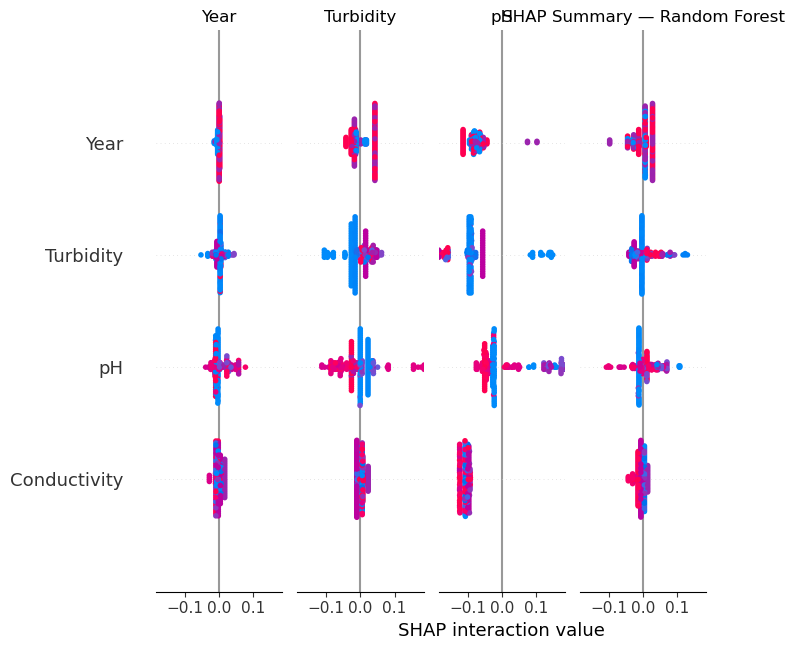

Saved: shap_summary.png

 Done! Best model: Decision Tree
Model            Decision Tree
Accuracy                   1.0
Precision                  1.0
Recall                     1.0
F1 Score                   1.0
MCC                        1.0
5-Fold CV Acc    0.996 ± 0.008
Name: 0, dtype: object


In [22]:
# 15. SHAP ANALYSIS (best tree-based model)
try:
    import shap
 
    shap_model_name = None
    for preferred in ["Random Forest", "Gradient Boosting", "XGBoost", "Decision Tree"]:
        if preferred in best_models:
            shap_model_name = preferred
            break
 
    shap_model    = best_models[shap_model_name]
    feature_names = list(X.columns)
 
    explainer   = shap.TreeExplainer(shap_model)
    shap_sample = X_train_sm[:200] if len(X_train_sm) > 200 else X_train_sm
    shap_values = explainer.shap_values(shap_sample)
 
    # Multi-class: shap_values is a list (one array per class)
    if isinstance(shap_values, list):
        mean_importance = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
        sorted_idx = np.argsort(mean_importance)[::-1]
        plt.figure(figsize=(8, 5))
        plt.barh([feature_names[i] for i in sorted_idx],
                 mean_importance[sorted_idx], color='steelblue')
        plt.xlabel("Mean |SHAP value| (averaged over classes)")
        plt.title(f"SHAP Feature Importance — {shap_model_name} (Surface Water)")
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.savefig("shap_importance.png", dpi=150)
        plt.show()
        print("Saved: shap_importance.png")
    else:
        shap.summary_plot(shap_values, shap_sample,
                          feature_names=feature_names, show=False)
        plt.title(f"SHAP Summary — {shap_model_name}")
        plt.tight_layout()
        plt.savefig("shap_summary.png", dpi=150, bbox_inches='tight')
        plt.show()
        print("Saved: shap_summary.png")
 
except ImportError:
    print("SHAP not installed. Run: pip install shap")
 
print(f"\n Done! Best model: {best_name}")
print(results_df.iloc[0])